# 토스 유저 오프라인 코호트 분할 — 1차 검증

**한 줄 답:** 기존 GA4 저장 집계의 토스 관측 기기 49대를 첫 관측일의 의도적 행동 수로 4개 배타 집단으로 나눴다. 영역 도달은 겹치는 보조 축이다. 아직 라벨·모델 학습은 하지 않았다.

**통과 기준(결과 확인 전):** 깊이 4집단의 기기 수 합계가 49, 경계가 겹치지 않아야 한다. 영역 축은 중복 도달을 명시하며 교차표를 추정하지 않는다.

**원천 SQL:** [`../sql/g2_toss_first_day_behavior.sql`](../sql/g2_toss_first_day_behavior.sql). `platform='toss'`인 GA4 완전 일별 export(2026-09-04~12 KST)에서 `user_pseudo_id`별 첫 토스 관측일을 잡고, `beta_A/B` 표시 기기와 자동·로그인·장부 이벤트를 제외했다. 출력은 기기 ID 없는 집계 CSV다. 신규 쿼리는 실행하지 않았다. `platform` 기록 이전 이탈, 미표시 베타 테스터는 누락/혼입 가능하다.


In [1]:
from pathlib import Path
import sys
import pandas as pd
from IPython.display import display
root = Path.cwd().parents[1] if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(root / 'ml'))
from calm_ml import report as R
R.setup()
src = root / 'ml/reports/g2_toss_behavior_2026-09-14'
depth = pd.read_csv(src / 'action_depth.csv')
breadth = pd.read_csv(src / 'area_count_distribution.csv')
area = pd.read_csv(src / 'area_reach.csv')
deep = pd.read_csv(root / 'ml/reports/g2_toss_deep_device_2026-09-14/deep_device_summary.csv')
n = int(depth['기기 수'].sum())
assert n == 49 and depth['행동 이벤트 수'].tolist() == ['0회', '1~5회', '6~30회', '31회 이상']
assert int(breadth['기기 수'].sum()) == n
depth['전체 대비 %'] = (100 * depth['기기 수'] / n).round(1)
display(depth)
display(breadth)
display(area[['영역', '도달 기기']])
print('상위 10대 행동 이벤트 비중:', round(100 * deep['전체_행동_비중'].sum(), 1), '%')


,행동 이벤트 수,기기 수,전체 대비 %
0,0회,22,44.9
1,1~5회,9,18.4
2,6~30회,8,16.3
3,31회 이상,10,20.4


,영역 수,기기 수
0,0,22
1,1,8
2,2,5
3,3,4
4,4,4
5,5,6


,영역,도달 기기
0,자연·채집,20
1,낚시·바다,9
2,퀘스트·교류,20
3,제작·집,13
4,고급 콘텐츠,14


상위 10대 행동 이벤트 비중: 95.7 %


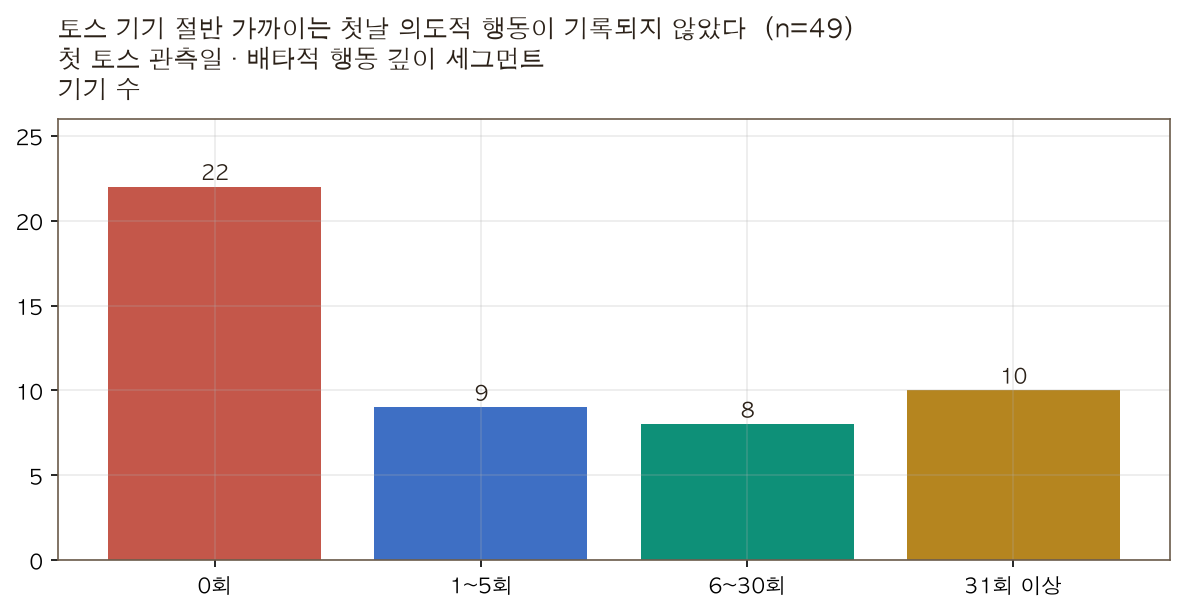

In [2]:
fig, ax = R.new('토스 기기 절반 가까이는 첫날 의도적 행동이 기록되지 않았다', n, sub='첫 토스 관측일 · 배타적 행동 깊이 세그먼트', ylab='기기 수')
bars = ax.bar(depth['행동 이벤트 수'], depth['기기 수'], color=R.PALETTE[:4])
for bar, count in zip(bars, depth['기기 수']):
    ax.text(bar.get_x() + bar.get_width()/2, count + 0.4, str(count), ha='center')
ax.set_ylim(0, 26)
fig.tight_layout()
out = root / 'ml/reports/g2_toss_segments_2026-09-14'
out.mkdir(parents=True, exist_ok=True)
chart = out / 'first_day_depth.png'
fig.savefig(chart, dpi=150)
display(R.show(chart))


## 해석과 한계

- **배타적 깊이 세그먼트:** 0회 22대(44.9%), 1~5회 9대(18.4%), 6~30회 8대(16.3%), 31회 이상 10대(20.4%). 4집단 합계 49대. 0회는 게임을 안 했다는 뜻이 아니라 *정의한 의도적 행동 이벤트가 첫 토스 관측일에 없다*는 뜻이다.
- **영역 폭:** 0영역 22대, 1영역 8대, 2영역 5대, 3영역 4대, 4영역 4대, 5영역 6대. 3영역 이상은 14대(28.6%). 이 축은 깊이 집단과의 교차표가 없어 결합 세그먼트 크기를 말할 수 없다.
- **행동 영역 도달:** 자연·채집 20대, 퀘스트·교류 20대, 제작·집 13대, 고급 콘텐츠 14대, 낚시·바다 9대. 한 기기가 여러 영역에 속하므로 합계가 49를 넘는다. 낚시 캐스트 자체는 별도 과거 감사에서 6대였다.
- **행동량 쏠림:** 행동 31회 이상인 10대가 기록된 의도적 행동의 약 95.7%를 차지한다. 평균 행동 수는 대표 기기의 경험이 아니다. 이 값은 저장된 상위 10대 요약을 재합산한 것이라 원시 로그 재조회가 아니다.

## 이 숫자로 말할 수 없는 것

관측 기간이 짧고 식별키가 기기 단위이며 `platform` 태그 전 이탈을 놓칠 수 있다. 0회 집단을 이탈자라고 단정하거나, 31회 이상 집단을 재방문자라고 부를 수 없다. 영역 간 차이는 인과효과가 아니다. 저장 CSV에는 기기별 행이 없어 깊이×영역 교차 세그먼트, 시간순 피처·라벨, 누수 검사를 할 수 없다. **모델 학습 표본 확정은 보류.**

## 다음에 확인할 것

다음 게이트에서 기존 BigQuery 로그를 기기별·시간순으로 다시 추출해 첫날 전반부 행동을 입력으로, 이후 행동/재방문을 라벨 후보로 분리한다. 코호트별 양성 수와 관측 종료 시점, 시간 누수를 확인한 뒤 모델링 여부를 판단한다. 여기서 멈춘다.
